# Tugas 1 - Klasifikasi Jamur dengan Naive Bayes

| Nama | NRP |
|------|-----|
| Muhammad Fasya Atthaya Rosyada | 5054251006 |

## Deskripsi Tugas
Pada tugas ini, kita akan menggunakan Mushroom Dataset dari UCI Machine Learning Repository.

Dataset dapat diakses melalui:
- https://www.kaggle.com/datasets/uciml/mushroom-classification

Untuk metadata / penjelasan mengenai dataset bisa mengakses link berikut:
- https://archive.ics.uci.edu/dataset/73/mushroom

Tujuan utama dari tugas ini adalah membangun dan membandingkan tiga varian Naive Bayes, yaitu Categorical NB, Bernoulli NB, dan Multinomial NB, untuk mengklasifikasikan apakah suatu jamur dapat dimakan (edible) atau beracun (poisonous).

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan untuk masing-masing varian Naive Bayes.
3. Eksperimen Model
   - Bangun model Categorical NB, Bernoulli NB, dan Multinomial NB.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil ketiga model dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [84]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, seaborn, sklearn, dll)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.naive_bayes import CategoricalNB, BernoulliNB, MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, roc_auc_score

In [ ]:
# Load dataset dan tampilkan beberapa baris pertama.
# Semua nilai pada dataset berupa single character yang merupakan kode singkatan dari kategori.
# Contoh: pada kolom class, e = edible dan p = poisonous.
df = pd.read_csv('mushrooms.csv')
display(df.head())

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [ ]:
# Tampilkan informasi dasar dataset: jumlah baris dan kolom, tipe data, dan jumlah missing value.
# Perhatikan kolom stalk-root yang memiliki nilai '?' sebagai representasi missing value.
print("Informasi Dataset:")
display(df.info())

print("\nPengecekan Missing Value Awal (Null):")
display(df.isnull().sum())

count_missing = (df['stalk-root'] == '?').sum()
print(f"\nJumlah nilai '?' pada stalk-root: {count_missing}")

Informasi Dataset:
<class 'pandas.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   class                     8124 non-null   str  
 1   cap-shape                 8124 non-null   str  
 2   cap-surface               8124 non-null   str  
 3   cap-color                 8124 non-null   str  
 4   bruises                   8124 non-null   str  
 5   odor                      8124 non-null   str  
 6   gill-attachment           8124 non-null   str  
 7   gill-spacing              8124 non-null   str  
 8   gill-size                 8124 non-null   str  
 9   gill-color                8124 non-null   str  
 10  stalk-shape               8124 non-null   str  
 11  stalk-root                8124 non-null   str  
 12  stalk-surface-above-ring  8124 non-null   str  
 13  stalk-surface-below-ring  8124 non-null   str  
 14  stalk-color-above-ring    8124 n

None


Pengecekan Missing Value Awal (Null):


class                       0
cap-shape                   0
cap-surface                 0
cap-color                   0
bruises                     0
odor                        0
gill-attachment             0
gill-spacing                0
gill-size                   0
gill-color                  0
stalk-shape                 0
stalk-root                  0
stalk-surface-above-ring    0
stalk-surface-below-ring    0
stalk-color-above-ring      0
stalk-color-below-ring      0
veil-type                   0
veil-color                  0
ring-number                 0
ring-type                   0
spore-print-color           0
population                  0
habitat                     0
dtype: int64


Jumlah nilai '?' pada stalk-root: 2480


In [87]:
# Tampilkan jumlah nilai unik pada setiap fitur.
# Perhatikan variasi jumlah kategori antar fitur, misalnya veil-type hanya punya 1 nilai unik.
display(df.nunique())

class                        2
cap-shape                    6
cap-surface                  4
cap-color                   10
bruises                      2
odor                         9
gill-attachment              2
gill-spacing                 2
gill-size                    2
gill-color                  12
stalk-shape                  2
stalk-root                   5
stalk-surface-above-ring     4
stalk-surface-below-ring     4
stalk-color-above-ring       9
stalk-color-below-ring       9
veil-type                    1
veil-color                   4
ring-number                  3
ring-type                    5
spore-print-color            9
population                   6
habitat                      7
dtype: int64

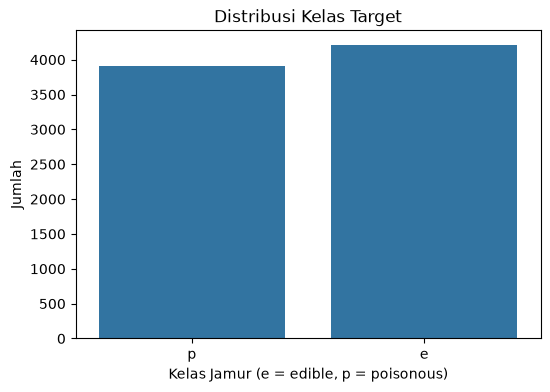

Persentase Edibel (e): 51.80%
Persentase Poisonous (p): 48.20%


In [105]:
# Tampilkan distribusi kelas target (class) dalam bentuk bar plot.
# Perhatikan apakah dataset ini imbalanced.
plt.figure(figsize=(6, 4))
sns.countplot(x='class', data=df)
plt.title('Distribusi Kelas Target')
plt.xlabel('Kelas Jamur (e = edible, p = poisonous)')
plt.ylabel('Jumlah')
plt.show()

rasio = df["class"].value_counts(normalize=True) * 100
print(f"Persentase Edibel (e): {rasio['e']:.2f}%")
print(f"Persentase Poisonous (p): {rasio['p']:.2f}%")

## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

# 2. Preprocessing

Karena semua fitur bertipe kategorikal, setiap varian Naive Bayes membutuhkan representasi data yang berbeda:

| Model | Representasi yang dibutuhkan | Preprocessing |
|---|---|---|
| Categorical NB | Integer per kategori | OrdinalEncoder |
| Bernoulli NB | Binary 0/1 per kategori | LabelBinarizer / OneHotEncoder |
| Multinomial NB | Count / frekuensi non-negatif | OneHotEncoder |

In [89]:
# Tangani missing value pada kolom stalk-root (nilai '?').
# Pilih strategi yang sesuai: drop baris, ganti dengan modus, atau jadikan kategori tersendiri.
df['stalk-root'] = df['stalk-root'].replace('?', 'm')

In [90]:
# Periksa apakah ada fitur yang hanya memiliki satu nilai unik.
# Fitur seperti itu tidak memberikan informasi apapun dan sebaiknya di-drop.
cols_to_drop = [col for col in df.columns if df[col].nunique() == 1]
print("Kolom yang di-drop karena hanya punya 1 nilai unik:", cols_to_drop)

df = df.drop(columns=cols_to_drop)

Kolom yang di-drop karena hanya punya 1 nilai unik: ['veil-type']


In [91]:
# Pisahkan fitur (X) dan target (y).
# Encode target: e = 0 (edible), p = 1 (poisonous).
# Bagi data menjadi train set dan test set (misalnya 80:20).
# Gunakan stratify=y agar distribusi kelas tetap proporsional.
X = df.drop('class', axis=1)
y = df['class'].map({'e': 0, 'p': 1})
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [92]:
# Preprocessing untuk Categorical NB:
# Gunakan OrdinalEncoder untuk mengubah setiap kategori menjadi integer.
# Contoh: cap-shape b=0, c=1, f=2, k=3, s=4, x=5
# Fit hanya pada train set, transform pada train set dan test set.
ord_enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

X_train_ord = ord_enc.fit_transform(X_train)
X_test_ord = ord_enc.transform(X_test)

In [93]:
# Preprocessing untuk Bernoulli NB dan Multinomial NB:
# Gunakan OneHotEncoder untuk mengubah setiap kategori menjadi representasi binary.
# Hasilnya berupa matriks sparse dengan nilai 0 dan 1.
# Fit hanya pada train set, transform pada train set dan test set.
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

X_train_ohe = ohe.fit_transform(X_train)
X_test_ohe = ohe.transform(X_test)

# 3. Eksperimen Model

## 3.1 Categorical Naive Bayes

CategoricalNB adalah varian yang paling sesuai untuk dataset ini karena semua fitur memang bertipe kategorikal. Model menghitung P(fitur=kategori | kelas) secara langsung untuk setiap kategori pada setiap fitur.

In [94]:
# Inisialisasi dan latih model CategoricalNB menggunakan train set hasil OrdinalEncoder.
cnb = CategoricalNB()
cnb.fit(X_train_ord, y_train)

,"alpha alpha: float, default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"min_categories min_categories: int or array-like of shape (n_features,), default=NoneMinimum number of categories per feature.- integer: Sets the minimum number of categories per feature to `n_categories` for each features.- array-like: shape (n_features,) where `n_categories[i]` holds the minimum number of categories for the ith column of the input.- None (default): Determines the number of categories automatically from the training data... versionadded:: 0.24",None
Name,Type,Value
"category_count_ category_count_: list of arrays of shape (n_features,)Holds arrays of shape (n_classes, n_categories of respective feature)for each feature. Each array provides the number of samplesencountered for each class and category of the specific feature.",list,"[array([[ 324.... 0., 1382.]]), array([[1248....134., 1368.]]), array([[ 38.... 542.]]), array([[1161....634., 499.]]), ...]"
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](2,)","[3366.,3133.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](2,)","[-0.66,-0.73]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"feature_log_prob_ feature_log_prob_: list of arrays of shape (n_features,)Holds arrays of shape (n_classes, n_categories of respective feature)for each feature. Each array provides the empirical log probabilityof categories given the respective feature and class, ``P(x_i|y)``.",list,"[array([[-2.33...-0.81964923]]), array([[-0.99...-0.82918638]]), array([[-4.46...-1.75582372]]), array([[-1.06...-1.83577635]]), ...]"


In [95]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label dan probabilitas kelas 1 untuk keperluan evaluasi.
y_pred_cnb = cnb.predict(X_test_ord)
y_prob_cnb = cnb.predict_proba(X_test_ord)[:, 1]

## 3.2 Bernoulli Naive Bayes

BernoulliNB bekerja pada representasi binary. Dengan OneHotEncoder, setiap kategori menjadi kolom tersendiri bernilai 0 atau 1, sehingga model memperlakukan setiap kategori sebagai fitur binary ada/tidak ada.

In [96]:
# Inisialisasi dan latih model BernoulliNB menggunakan train set hasil OneHotEncoder.
bnb = BernoulliNB()
bnb.fit(X_train_ohe, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"binarize binarize: float or None, default=0.0Threshold for binarizing (mapping to booleans) of sample features.If None, input is presumed to already consist of binary vectors.",0.0
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](2,)","[3366.,3133.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Log probability of each class (smoothed).","ndarray[float64](2,)","[-0.66,-0.73]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](2, 116)","[[ 324., 0.,1276.,..., 109., 80., 157.], [ 37., 4.,1241.,..., 782., 221., 0.]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of features given a class, P(x_i|y).","ndarray[float64](2, 116)","[[-2.34,-8.12,-0.97,...,-3.42,-3.73,-3.06], [-4.41,-6.44,-0.93,...,-1.39,-2.65,-8.05]]"


In [97]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label dan probabilitas kelas 1 untuk keperluan evaluasi.
y_pred_bnb = bnb.predict(X_test_ohe)
y_prob_bnb = bnb.predict_proba(X_test_ohe)[:, 1]

## 3.3 Multinomial Naive Bayes

MultinomialNB membutuhkan input non-negatif dan menginterpretasikannya sebagai frekuensi. Dengan OneHotEncoder yang menghasilkan nilai 0 dan 1, model dapat menerimanya sebagai counts meskipun secara semantik tiap nilai hanya menandakan ada/tidak ada kategori.

In [98]:
# Inisialisasi dan latih model MultinomialNB menggunakan train set hasil OneHotEncoder.
mnb = MultinomialNB()
mnb.fit(X_train_ohe, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](2,)","[3366.,3133.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](2,)","[-0.66,-0.73]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](2, 116)","[[ 324., 0.,1276.,..., 109., 80., 157.], [ 37., 4.,1241.,..., 782., 221., 0.]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of featuresgiven a class, ``P(x_i|y)``.","ndarray[float64](2, 116)","[[ -5.38,-11.17, -4.02,..., -6.47, -6.77, -6.11], [ -7.46, -9.49, -3.97,..., -4.43, -5.69,-11.1 ]]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,116


In [99]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label dan probabilitas kelas 1 untuk keperluan evaluasi.
y_pred_mnb = mnb.predict(X_test_ohe)
y_prob_mnb = mnb.predict_proba(X_test_ohe)[:, 1]

# 4. Evaluasi Model

In [100]:
# Tampilkan metrik evaluasi untuk setiap model: Accuracy, Precision, Recall, dan F1-Score.
# Sajikan dalam satu tabel perbandingan agar mudah dibandingkan.
results = {
    "Categorical NB": [accuracy_score(y_test, y_pred_cnb), precision_score(y_test, y_pred_cnb), recall_score(y_test, y_pred_cnb), f1_score(y_test, y_pred_cnb)],
    "Bernoulli NB": [accuracy_score(y_test, y_pred_bnb), precision_score(y_test, y_pred_bnb), recall_score(y_test, y_pred_bnb), f1_score(y_test, y_pred_bnb)],
    "Multinomial NB": [accuracy_score(y_test, y_pred_mnb), precision_score(y_test, y_pred_mnb), recall_score(y_test, y_pred_mnb), f1_score(y_test, y_pred_mnb)]
}

df_results = pd.DataFrame(results, index=['Accuracy', 'Precision', 'Recall', 'F1-Score']).T
display(df_results)

,Accuracy,Precision,Recall,F1-Score
Categorical NB,0.945846,0.990127,0.896552,0.941019
Bernoulli NB,0.932923,0.981429,0.877395,0.926500
Multinomial NB,0.945846,0.990127,0.896552,0.941019


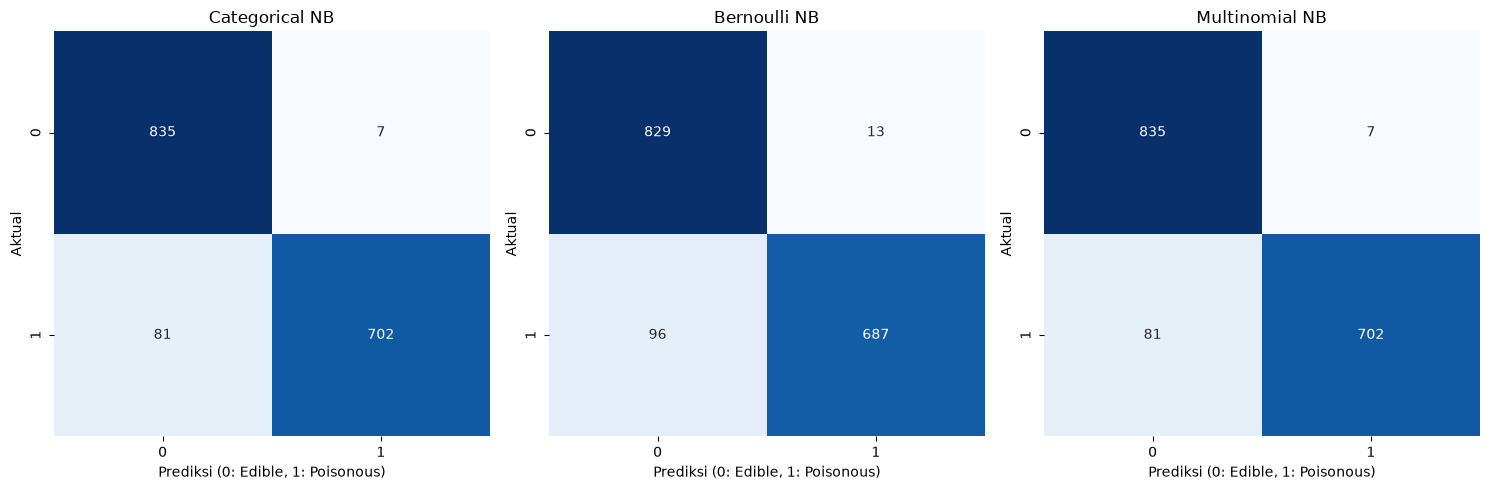

In [101]:
# Tampilkan Confusion Matrix setiap model dalam bentuk heatmap.
# Susun ketiganya dalam satu baris subplot.
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
models_pred = [y_pred_cnb, y_pred_bnb, y_pred_mnb]
titles = ['Categorical NB', 'Bernoulli NB', 'Multinomial NB']

for ax, pred, title in zip(axes, models_pred, titles):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False)
    ax.set_title(title)
    ax.set_xlabel('Prediksi (0: Edible, 1: Poisonous)')
    ax.set_ylabel('Aktual')

plt.tight_layout()
plt.show()

C:\Users\Pongo\AppData\Local\Temp\ipykernel_20696\1346047311.py:10: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot([0, 1], [0, 1], 'k--', color='gray')


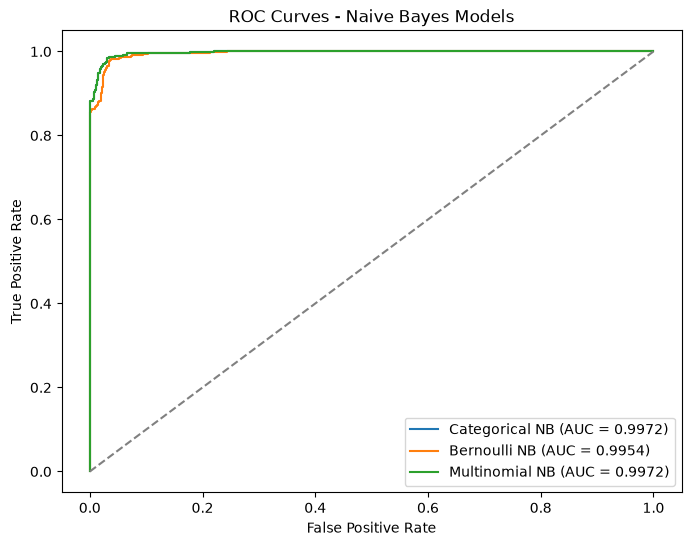

In [102]:
# Tampilkan ROC Curve ketiga model dalam satu plot beserta nilai AUC masing-masing.
plt.figure(figsize=(8, 6))
models_prob = [y_prob_cnb, y_prob_bnb, y_prob_mnb]

for prob, label in zip(models_prob, titles):
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc_score = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, label=f'{label} (AUC = {auc_score:.4f})')

plt.plot([0, 1], [0, 1], 'k--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Naive Bayes Models')
plt.legend(loc='lower right')
plt.show()

# 5. Analisis

### Analisis Hasil Eksperimen

Berdasarkan hasil eksperimen yang telah dijalankan, berikut adalah poin-poin analisis utama:

- **Performa Keseluruhan:** Ketiga varian Naive Bayes menunjukkan performa yang sangat baik dengan tingkat akurasi di atas 93%. **Categorical Naive Bayes** dan **Multinomial Naive Bayes** mencapai tingkat *Accuracy* dan *F1-Score* tertinggi (sekitar 94.5%). Sebaliknya, **Bernoulli Naive Bayes** memiliki performa sedikit di bawah dua model lainnya (Akurasi ~93.2%).

- **Pengaruh Representasi Data:**
  - **Categorical NB:** Model ini sangat optimal untuk dataset *Mushroom* karena arsitekturnya dirancang murni untuk fitur kategorikal (menggunakan *OrdinalEncoder*).
  - **Bernoulli NB:** Menggunakan *One-Hot Encoding* untuk merubah kategori menjadi biner (0 dan 1). BernoulliNB mengasumsikan keberadaan atau ketiadaan fitur secara independen. Penurunan *recall* (lebih banyak *False Negatives*) terjadi karena pemisahan kategori menjadi kolom biner terpisah merubah distribusi probabilitas bersyarat yang ditangkap oleh model.
  - **Multinomial NB:** Walaupun awalnya didesain untuk menghitung frekuensi, input berbasis matriks OHE (0 dan 1) tetap dapat diproses sebagai "frekuensi" eksistensi fitur. Hasilnya identik dengan *Categorical NB* pada dataset ini, menunjukkan bahwa perhitungan multiklasifikasinya adaptif terhadap pemetaan fitur biner tanpa penalti komputasi.

- **Keamanan Konsumsi (Recall vs Precision):** Pada kasus jamur, mengklasifikasikan jamur beracun sebagai dapat dimakan (*False Negative*) sangat berbahaya. Meskipun *Precision* tinggi pada semua model, nilai *Recall* berada di kisaran 87-89%. Artinya, sekitar 10-13% jamur beracun dalam data *test* lolos dari deteksi prediksi beracun.

# 6. Kesimpulan dan Saran

### Kesimpulan

Algoritma Naive Bayes terbukti efisien dan sangat cepat untuk mengklasifikasikan *Mushroom Dataset* tanpa memerlukan pengaturan *hyperparameter* yang rumit. Variasi representasi fitur sangat menentukan keberhasilan prediksi, di mana representasi ordinal (*Categorical NB*) dan *One-Hot Encoding* (*Multinomial NB*) memberikan hasil prediksi terbaik yang paling seimbang.

### Saran

1. **Model Alternatif:** Meski hasil akurasi model sudah tinggi, persentase *False Negatives* (jamur beracun ditebak *edible*) masih ada (sekitar 100 sampel di data *test*). Dalam kasus nyata di mana nyawa manusia menjadi taruhan, tingkat toleransi kesalahan ini kurang bisa diterima. Sangat disarankan untuk mencoba algoritma berbasis *Decision Tree* (seperti Random Forest atau XGBoost) yang sering kali mampu mencapai akurasi 100% pada dataset ini.
2. **Threshold Probabilitas:** Untuk model Naive Bayes ini, demi faktor keamanan, *decision threshold* (ambang batas) probabilitas dapat diturunkan. Alih-alih menggunakan standar probabilitas `> 0.5` untuk menebak kelas *poisonous*, batas ini dapat diturunkan ke angka `> 0.2` atau `> 0.3` agar sistem menjadi jauh lebih sensitif dalam mendeteksi status beracun pada jamur.